# 07. Causal DAGs and Graphical Assumptions

Causal inference begins before estimation. We first need to say what we believe about how the variables in the problem are connected. Directed acyclic graphs, usually called DAGs, give us a compact language for writing those assumptions down.

A DAG is useful because it forces three questions into the open:

1. What causes what?
2. Which variables create non-causal association between treatment and outcome?
3. Which variables should we adjust for, avoid adjusting for, or treat as part of the causal mechanism?

This lecture is about that third question. We will use Graphviz diagrams, small simulations, and regression examples to see why a variable can be helpful in one graph and harmful in another.

The most important lesson is this:

> A variable becomes a confounder through its role in the causal graph, not through correlation alone.

DAGs are therefore not decorative diagrams. They are working objects. They encode the assumptions that determine whether an effect can be identified from the data (Pearl, 1995; Greenland et al., 1999; Shrier & Platt, 2008).

## Learning Goals

By the end of this notebook, you should be able to:

- Read a DAG as a set of causal assumptions.
- Distinguish confounders, mediators, colliders, and descendants.
- Explain why conditioning can either block bias or create bias.
- Use the back-door idea to choose adjustment variables.
- Recognize why DAGs require subject-matter knowledge and cannot be replaced by correlation screening.
- Translate a business problem into a graphical adjustment strategy.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
palette = {
    "treatment": "#2f6f9f",
    "outcome": "#b23a48",
    "covariate": "#4f772d",
    "mechanism": "#9a6f2e",
    "warning": "#c76d22",
    "latent": "#666666",
}

rng = np.random.default_rng(20260428)

from notebooks._shared.display import smart_display

## 1. What a DAG Means

A DAG has three parts:

- **Nodes** are variables.
- **Directed arrows** represent direct causal effects in the graph.
- **Acyclic** means arrows cannot form a directed loop. A variable cannot cause itself through a closed directed cycle in the same graph.

For example, in an industry retention problem, customer intent may affect whether a customer receives a retention offer. Intent may also affect whether the customer renews. The offer may affect renewal. That gives us a classic confounding structure:

$$
\text{Intent} \rightarrow \text{Offer}, \qquad
\text{Intent} \rightarrow \text{Renewal}, \qquad
\text{Offer} \rightarrow \text{Renewal}.
$$

If we compare offered customers to non-offered customers without accounting for intent, the comparison mixes the causal effect of the offer with pre-existing customer differences.

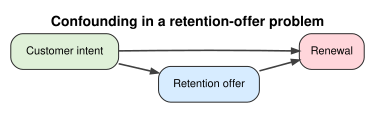

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR", graph_attr=None):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
        graph_attr: Additional Graphviz layout attributes for spacing and sizing.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.15", nodesep="0.45", ranksep="0.55")
    dot.attr("node", shape="box", style="rounded,filled", color="#2b2b2b", fontname="Helvetica", fontsize="11", margin="0.12,0.08")
    dot.attr("edge", color="#404040", arrowsize="0.75", penwidth="1.6", fontname="Helvetica", fontsize="10")
    if graph_attr:
        dot.attr(**graph_attr)
    if title:
        dot.attr(label=title, labelloc="t", fontsize="14", fontname="Helvetica-Bold")
    nodes = sorted(set([x for edge in edges for x in edge[:2]]))
    for node in nodes:
        fill = node_colors.get(node, "#f7f7f7")
        dot.node(node, fillcolor=fill)
    for edge in edges:
        if len(edge) == 2:
            src, dst = edge
            attrs = {}
        else:
            src, dst, attrs = edge
        dot.edge(src, dst, **attrs)
    return dot

retention_edges = [
    ("Customer intent", "Retention offer"),
    ("Customer intent", "Renewal"),
    ("Retention offer", "Renewal"),
]
retention_colors = {
    "Retention offer": "#d7ecff",
    "Renewal": "#ffd6db",
    "Customer intent": "#dff0d8",
}

smart_display(make_dag(retention_edges, "Confounding in a retention-offer problem", retention_colors))

The graph says that customer intent is a common cause of treatment and outcome. In words:

- Customers with high intent may be less likely to receive an offer because the firm saves incentives for customers at risk.
- Customers with high intent may be more likely to renew anyway.
- The offer itself may change renewal.

The observed association between offer and renewal therefore needs a design argument before it can be read causally. We need to compare offered and non-offered customers who are similar in intent, or design an experiment where offer assignment no longer depends on intent.

## 2. Basic Graph Vocabulary

The following vocabulary is the foundation for reading adjustment problems.

| Term | Meaning | Why it matters |
|---|---|---|
| Parent | A direct cause of a node | Parent variables often explain why treatment or outcome varies |
| Child | A direct effect of a node | Adjusting for children of treatment can change the estimand |
| Ancestor | A cause, direct or indirect | Ancestors of treatment and outcome can create confounding |
| Descendant | An effect, direct or indirect | Descendants can create post-treatment adjustment problems |
| Path | Any route connecting two nodes, ignoring arrow direction | Bias travels along open non-causal paths |
| Directed path | A path where all arrows point forward | Directed paths carry causal effects |
| Back-door path | A path from treatment to outcome that starts with an arrow into treatment | Back-door paths are the paths we try to block for total-effect identification |
| Collider | A node where two arrows meet head-to-head | Conditioning on colliders can open biasing paths |

DAG language is precise because the same variable can play different roles in different graphs. A variable named `engagement` could be a confounder, a mediator, a collider, or a proxy depending on when it is measured and what causes it.

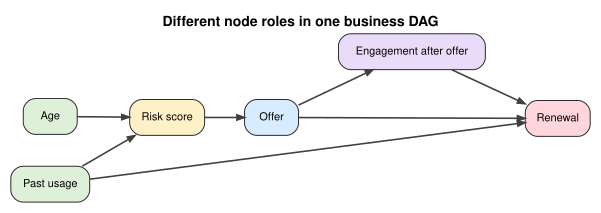

In [3]:
# Organize the calculation into readable steps for the lecture narrative.
vocabulary_edges = [
    ("Age", "Risk score"),
    ("Past usage", "Risk score"),
    ("Risk score", "Offer"),
    ("Past usage", "Renewal"),
    ("Offer", "Engagement after offer"),
    ("Engagement after offer", "Renewal"),
    ("Offer", "Renewal"),
]
vocabulary_colors = {
    "Offer": "#d7ecff",
    "Renewal": "#ffd6db",
    "Age": "#dff0d8",
    "Past usage": "#dff0d8",
    "Risk score": "#fff1c7",
    "Engagement after offer": "#eadcf8",
}

smart_display(make_dag(vocabulary_edges, "Different node roles in one business DAG", vocabulary_colors))

This graph separates pre-treatment variables from post-treatment variables.

- `Past usage` is pre-treatment and affects both risk scoring and renewal. It is a plausible adjustment variable.
- `Risk score` affects treatment assignment. If it was computed before the offer, it can help account for targeting.
- `Engagement after offer` is post-treatment. Adjusting for it would remove part of the offer's effect if the estimand is the total effect of the offer on renewal.

This is why timestamps matter. DAGs should be built with temporal order in mind.

## 3. Three Path Patterns: Chain, Fork, Collider

Most DAG intuition comes from three small structures.

### Chain

$$
A \rightarrow B \rightarrow C
$$

Information can flow from `A` to `C` through `B`. Conditioning on `B` blocks that path.

### Fork

$$
A \leftarrow B \rightarrow C
$$

`B` is a common cause. `A` and `C` are associated because they share a cause. Conditioning on `B` blocks that path.

### Collider

$$
A \rightarrow B \leftarrow C
$$

`B` is a common effect. `A` and `C` are typically not associated through that path unless we condition on `B` or a descendant of `B`. Conditioning on a collider opens the path.

The collider rule is the one people most often violate in practice. It explains why filtering data to selected users, responders, admitted cases, approved loans, or customers with observed outcomes can create selection bias (Greenland et al., 1999; Shrier & Platt, 2008).

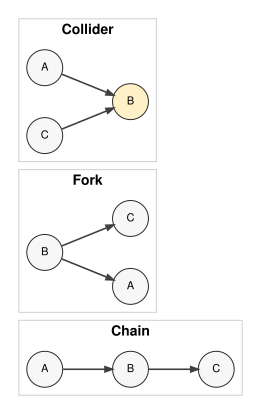

In [4]:
# Organize the calculation into readable steps for the lecture narrative.
pattern_edges = [
    ("A_chain", "B_chain"), ("B_chain", "C_chain"),
    ("B_fork", "A_fork"), ("B_fork", "C_fork"),
    ("A_collider", "B_collider"), ("C_collider", "B_collider"),
]
pattern_labels = {
    "A_chain": "A", "B_chain": "B", "C_chain": "C",
    "A_fork": "A", "B_fork": "B", "C_fork": "C",
    "A_collider": "A", "B_collider": "B", "C_collider": "C",
}

dot = Digraph(format="svg")
dot.attr(rankdir="LR", bgcolor="transparent", pad="0.15", nodesep="0.45", ranksep="0.7")
dot.attr("node", shape="circle", style="filled", color="#2b2b2b", fillcolor="#f7f7f7", fontname="Helvetica", fontsize="11")
dot.attr("edge", color="#404040", arrowsize="0.75", penwidth="1.6")

with dot.subgraph(name="cluster_chain") as c:
    c.attr(label="Chain", color="#d0d0d0", fontname="Helvetica-Bold")
    for n in ["A_chain", "B_chain", "C_chain"]:
        c.node(n, label=pattern_labels[n])
    c.edge("A_chain", "B_chain")
    c.edge("B_chain", "C_chain")

with dot.subgraph(name="cluster_fork") as c:
    c.attr(label="Fork", color="#d0d0d0", fontname="Helvetica-Bold")
    for n in ["A_fork", "B_fork", "C_fork"]:
        c.node(n, label=pattern_labels[n])
    c.edge("B_fork", "A_fork")
    c.edge("B_fork", "C_fork")

with dot.subgraph(name="cluster_collider") as c:
    c.attr(label="Collider", color="#d0d0d0", fontname="Helvetica-Bold")
    for n in ["A_collider", "B_collider", "C_collider"]:
        fill = "#fff1c7" if n == "B_collider" else "#f7f7f7"
        c.node(n, label=pattern_labels[n], fillcolor=fill)
    c.edge("A_collider", "B_collider")
    c.edge("C_collider", "B_collider")

smart_display(dot)

## 4. Simulating Path Behavior

Let us simulate the three structures and inspect correlations before and after conditioning. Correlation is not causal proof, but it is a useful way to see how conditioning changes statistical dependence.

**Dataset and experiment setup.** The simulations in this notebook are small causal laboratories. Each one creates data from a known graph, then asks what happens when we condition on different variables. The units change by example, such as customers, campaign recipients, or ranking decisions, but the purpose is the same: show how forks, chains, and colliders behave in data. Because the graph is known by construction, the notebook can separate a statistical pattern from the causal path that generated it. That makes the examples useful for teaching adjustment choices before moving to messier industry datasets.

In [5]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def residualize(y, x):
    """
    Remove the linear component of one variable explained by another variable.
    
    Idea:
        Residualization is used to show how conditioning changes the variation left for a causal or associational comparison.
    
    Args:
        y: Outcome vector used to form the comparison or IV numerator.
        x: Adjustment vector whose linear contribution is removed from y.
    
    Returns:
        numpy.ndarray: Residual values from regressing the outcome-like vector on the adjustment vector.
    """
    X = np.column_stack([np.ones(len(x)), x])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    return y - X @ beta

n = 50_000

# Chain: A -> B -> C
A_chain = rng.normal(size=n)
B_chain = 0.9 * A_chain + rng.normal(size=n)
C_chain = 0.9 * B_chain + rng.normal(size=n)

# Fork: B -> A and B -> C
B_fork = rng.normal(size=n)
A_fork = 0.9 * B_fork + rng.normal(size=n)
C_fork = 0.9 * B_fork + rng.normal(size=n)

# Collider: A -> B <- C
A_col = rng.normal(size=n)
C_col = rng.normal(size=n)
B_col = 0.9 * A_col + 0.9 * C_col + rng.normal(size=n)

path_results = pd.DataFrame({
    "structure": ["Chain: A -> B -> C", "Fork: A <- B -> C", "Collider: A -> B <- C"],
    "corr_A_C_marginal": [
        np.corrcoef(A_chain, C_chain)[0, 1],
        np.corrcoef(A_fork, C_fork)[0, 1],
        np.corrcoef(A_col, C_col)[0, 1],
    ],
    "corr_A_C_after_conditioning_on_B": [
        np.corrcoef(residualize(A_chain, B_chain), residualize(C_chain, B_chain))[0, 1],
        np.corrcoef(residualize(A_fork, B_fork), residualize(C_fork, B_fork))[0, 1],
        np.corrcoef(residualize(A_col, B_col), residualize(C_col, B_col))[0, 1],
    ],
})
path_results.round(3)

,structure,corr_A_C_marginal,corr_A_C_after_conditioning_on_B
0,Chain: A -> B -> C,0.513,-0.005
1,Fork: A <- B -> C,0.445,-0.001
2,Collider: A -> B <- C,0.005,-0.442


The simulation shows the core path rules.

- In the **chain**, `A` and `C` are associated before conditioning. After conditioning on the middle variable `B`, the association nearly disappears.
- In the **fork**, `A` and `C` are associated because they share a cause. After conditioning on the common cause `B`, the association nearly disappears.
- In the **collider**, `A` and `C` are close to independent before conditioning. After conditioning on their common effect `B`, a strong association appears.

This last result feels strange the first time you see it, but it is central to causal inference. Conditioning is not always harmless. Conditioning on the wrong variable can manufacture a relationship that was not there marginally.

## 5. Back-Door Paths and Adjustment

A back-door path from treatment `T` to outcome `Y` is a path that starts with an arrow pointing into `T`. In a simple confounding graph:

$$
U \rightarrow T, \qquad U \rightarrow Y, \qquad T \rightarrow Y.
$$

The path `T <- U -> Y` is a non-causal path. It creates association between treatment and outcome even if the treatment effect were zero. To identify the total effect of `T` on `Y`, we need to block that path, often by adjusting for `U` if it is measured.

Pearl's back-door criterion gives a graphical rule for sufficient adjustment sets in DAGs; later work extends this idea to more general graph classes and hidden-variable settings (Pearl, 1995; Maathuis & Colombo, 2015; Pearl & Paz, 2014).

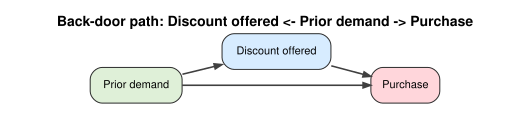

In [6]:
# Define the graph structure for the Back-Door Paths and Adjustment diagram.
confounding_edges = [
    ("Prior demand", "Discount offered"),
    ("Prior demand", "Purchase"),
    ("Discount offered", "Purchase"),
]
confounding_colors = {
    "Discount offered": "#d7ecff",
    "Purchase": "#ffd6db",
    "Prior demand": "#dff0d8",
}

smart_display(make_dag(confounding_edges, "Back-door path: Discount offered <- Prior demand -> Purchase", confounding_colors))

In Back-Door Paths and Adjustment, the figure makes the causal story visible before the estimate appears. Check the arrows and variable roles before trusting the number.

In [7]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_discount_confounding(n=60_000, seed=11):
    """Generate the synthetic discount confounding data used in 07. Causal DAGs and Graphical Assumptions.

    Args:
        n: Number of simulated units.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng_local = np.random.default_rng(seed)
    prior_demand = rng_local.normal(size=n)
    # The firm targets discounts to lower-demand customers.
    p_discount = 1 / (1 + np.exp(-(-0.4 - 1.2 * prior_demand)))
    discount = rng_local.binomial(1, p_discount)
    # True causal effect of discount on purchase probability scale is positive.
    purchase_latent = -0.2 + 0.75 * discount + 1.25 * prior_demand + rng_local.normal(size=n)
    purchase = (purchase_latent > 0).astype(int)
    return pd.DataFrame({
        "prior_demand": prior_demand,
        "discount": discount,
        "purchase": purchase,
        "p_discount": p_discount,
    })

df_discount = simulate_discount_confounding()

naive_model = smf.ols("purchase ~ discount", data=df_discount).fit()
adjusted_model = smf.ols("purchase ~ discount + prior_demand", data=df_discount).fit()

summary = pd.DataFrame({
    "estimator": ["Naive difference", "Adjusted for prior demand"],
    "discount_coefficient": [naive_model.params["discount"], adjusted_model.params["discount"]],
    "std_error": [naive_model.bse["discount"], adjusted_model.bse["discount"]],
})
summary.round(4)

,estimator,discount_coefficient,std_error
0,Naive difference,-0.1117,0.0041
1,Adjusted for prior demand,0.1935,0.0037


In Back-Door Paths and Adjustment, read the model output after checking the graph. The graph tells us whether the coefficient belongs to the estimand we care about.

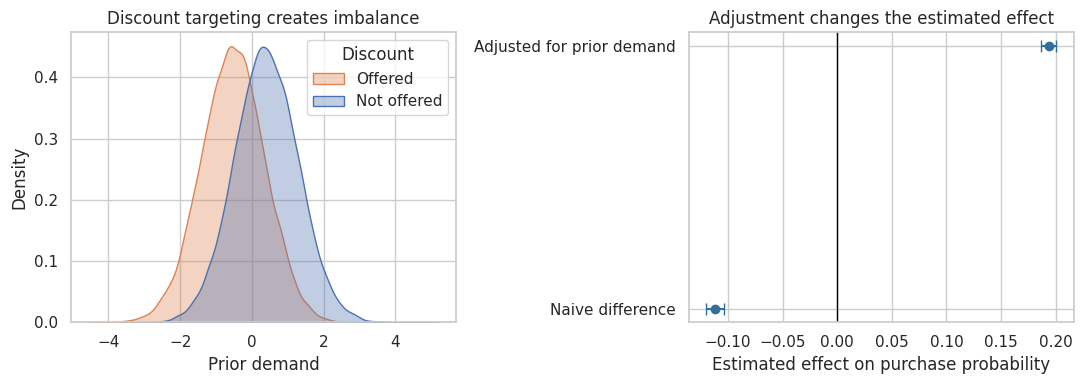

In [8]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.kdeplot(data=df_discount, x="prior_demand", hue="discount", common_norm=False, fill=True, alpha=0.35, ax=axes[0])
axes[0].set_title("Discount targeting creates imbalance")
axes[0].set_xlabel("Prior demand")
axes[0].legend(title="Discount", labels=["Offered", "Not offered"])

plot_df = summary.copy()
plot_df["lower"] = plot_df["discount_coefficient"] - 1.96 * plot_df["std_error"]
plot_df["upper"] = plot_df["discount_coefficient"] + 1.96 * plot_df["std_error"]
axes[1].errorbar(
    plot_df["discount_coefficient"],
    plot_df["estimator"],
    xerr=[plot_df["discount_coefficient"] - plot_df["lower"], plot_df["upper"] - plot_df["discount_coefficient"]],
    fmt="o",
    color="#2f6f9f",
    capsize=4,
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Adjustment changes the estimated effect")
axes[1].set_xlabel("Estimated effect on purchase probability")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In this simulation, discounts are targeted toward lower-demand customers. That means discounted customers look worse before the discount is applied. The naive comparison can understate the benefit of the discount, or even make a beneficial treatment look harmful.

After adjusting for `prior_demand`, the estimate moves toward the intended causal contrast: comparing customers with similar prior demand who differ in whether they received the discount.

The graph tells us why the adjustment is appropriate. The variable is pre-treatment and sits on a back-door path.

## 6. Good Adjustment: Blocking a Fork

A confounder is a common cause of treatment and outcome. In graph form, it is the middle of a fork:

$$
T \leftarrow X \rightarrow Y.
$$

Adjusting for `X` blocks the non-causal path from `T` to `Y`. In a randomized experiment, there should be no arrow from pre-treatment covariates into treatment assignment, so this path is absent by design.

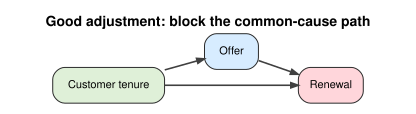

In [9]:
# Define the graph structure for the Good Adjustment: Blocking a Fork diagram.
good_adjustment_edges = [
    ("Customer tenure", "Offer"),
    ("Customer tenure", "Renewal"),
    ("Offer", "Renewal"),
]
good_adjustment_colors = {
    "Offer": "#d7ecff",
    "Renewal": "#ffd6db",
    "Customer tenure": "#dff0d8",
}

smart_display(make_dag(good_adjustment_edges, "Good adjustment: block the common-cause path", good_adjustment_colors))

When you adjust for a confounder, you are not saying the confounder is unimportant. You are saying the opposite: it is important enough that treated and untreated units must be made comparable with respect to it.

In applied work, this is often done with regression adjustment, stratification, matching, weighting, doubly robust estimation, or a design restriction. The DAG tells us what must be balanced; the estimator tells us how we attempt to balance it.

## 7. Bad Adjustment: Conditioning on a Mediator

A mediator lies on the causal pathway from treatment to outcome:

$$
T \rightarrow M \rightarrow Y.
$$

If the goal is the **total effect** of `T` on `Y`, adjusting for `M` blocks part of the effect we are trying to estimate.

Mediators are central for controlled direct effects and mediation estimands. For the total effect, post-treatment mediators should be handled as part of the causal pathway rather than ordinary controls.

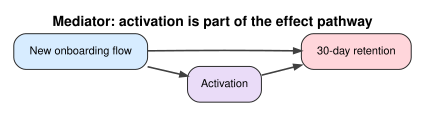

In [10]:
# Define the graph structure for the Bad Adjustment: Conditioning on a Mediator diagram.
mediator_edges = [
    ("New onboarding flow", "Activation"),
    ("Activation", "30-day retention"),
    ("New onboarding flow", "30-day retention"),
]
mediator_colors = {
    "New onboarding flow": "#d7ecff",
    "30-day retention": "#ffd6db",
    "Activation": "#eadcf8",
}

smart_display(make_dag(mediator_edges, "Mediator: activation is part of the effect pathway", mediator_colors))

In Bad Adjustment: Conditioning on a Mediator, the figure makes the causal story visible before the estimate appears. The graph should be settled before the estimate becomes the center of attention.

In [11]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_mediator(n=60_000, seed=22):
    """Generate the synthetic mediator data used in 07. Causal DAGs and Graphical Assumptions.

    Args:
        n: Number of simulated units.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng_local = np.random.default_rng(seed)
    treatment = rng_local.binomial(1, 0.5, size=n)
    activation = 0.9 * treatment + rng_local.normal(size=n)
    retention = 0.25 * treatment + 0.75 * activation + rng_local.normal(size=n)
    return pd.DataFrame({
        "treatment": treatment,
        "activation": activation,
        "retention": retention,
    })

df_mediator = simulate_mediator()

total_model = smf.ols("retention ~ treatment", data=df_mediator).fit()
direct_style_model = smf.ols("retention ~ treatment + activation", data=df_mediator).fit()

mediator_summary = pd.DataFrame({
    "model": ["Do not adjust for mediator", "Adjust for mediator"],
    "treatment_coefficient": [total_model.params["treatment"], direct_style_model.params["treatment"]],
    "interpretation": ["Total effect estimate", "Direct-effect-style estimate"],
})
mediator_summary.round(3)

,model,treatment_coefficient,interpretation
0,Do not adjust for mediator,0.927,Total effect estimate
1,Adjust for mediator,0.247,Direct-effect-style estimate


The treatment changes activation, and activation changes retention. When we do not adjust for activation, the treatment coefficient captures both the direct path and the indirect path through activation.

When we adjust for activation, we compare treated and untreated users with the same activation level. That removes the part of the treatment effect that works through activation. This may be useful for a mediation question, but it is not the total business impact of changing the onboarding flow.

## 8. Bad Adjustment: Conditioning on a Collider

A collider is a common effect:

$$
A \rightarrow C \leftarrow B.
$$

Conditioning on `C` can induce association between `A` and `B` even if they were otherwise independent. In industry data, colliders often appear through selection mechanisms:

- We only observe customers who clicked.
- We only analyze users who survived onboarding.
- We only measure satisfaction among respondents.
- We only evaluate loans that were approved.

If both treatment and outcome affect whether a row enters the analysis, conditioning on being observed can bias the effect estimate.

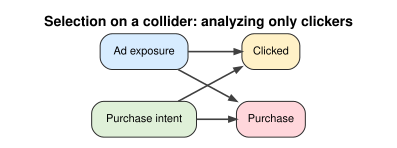

In [12]:
# Define the graph structure for the Bad Adjustment: Conditioning on a Collider diagram.
collider_edges = [
    ("Ad exposure", "Clicked"),
    ("Purchase intent", "Clicked"),
    ("Ad exposure", "Purchase"),
    ("Purchase intent", "Purchase"),
]
collider_colors = {
    "Ad exposure": "#d7ecff",
    "Purchase": "#ffd6db",
    "Purchase intent": "#dff0d8",
    "Clicked": "#fff1c7",
}

smart_display(make_dag(collider_edges, "Selection on a collider: analyzing only clickers", collider_colors))

In Bad Adjustment: Conditioning on a Collider, the figure makes the causal story visible before the estimate appears. A clean-looking estimate is useful only after the variable roles make sense.

In [13]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_collider_selection(n=100_000, seed=33):
    """Generate the synthetic collider selection data used in 07. Causal DAGs and Graphical Assumptions.

    Args:
        n: Number of simulated units.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng_local = np.random.default_rng(seed)
    ad = rng_local.binomial(1, 0.5, size=n)
    intent = rng_local.normal(size=n)
    # Clicking is caused by both exposure and intent.
    click_score = -0.7 + 1.0 * ad + 1.0 * intent + rng_local.normal(size=n)
    clicked = (click_score > 0).astype(int)
    # True ad effect is positive, and intent is also strongly predictive.
    purchase = 0.20 * ad + 0.80 * intent + rng_local.normal(size=n)
    return pd.DataFrame({
        "ad": ad,
        "intent": intent,
        "clicked": clicked,
        "purchase": purchase,
    })

df_click = simulate_collider_selection()

full_sample = smf.ols("purchase ~ ad + intent", data=df_click).fit()
clickers_only = smf.ols("purchase ~ ad + intent", data=df_click.query("clicked == 1")).fit()
naive_clickers = smf.ols("purchase ~ ad", data=df_click.query("clicked == 1")).fit()

click_summary = pd.DataFrame({
    "analysis": ["Full sample, adjust for intent", "Clickers only, adjust for intent", "Clickers only, no intent control"],
    "ad_coefficient": [full_sample.params["ad"], clickers_only.params["ad"], naive_clickers.params["ad"]],
    "sample_size": [len(df_click), int(df_click["clicked"].sum()), int(df_click["clicked"].sum())],
})
click_summary.round(3)

,analysis,ad_coefficient,sample_size
0,"Full sample, adjust for intent",0.194,100000
1,"Clickers only, adjust for intent",0.205,44632
2,"Clickers only, no intent control",-0.054,44632


The full-sample model recovers the ad effect well because it adjusts for purchase intent. The clickers-only analysis changes the population and conditions on a variable caused by both ad exposure and intent.

Among clickers, seeing an ad and having high prior intent become substitutes for explaining why the person clicked. That induced relationship can distort the effect estimate. This is one reason click-through data must be handled carefully when the final outcome is purchase, renewal, or lifetime value.

## 9. Adjustment Sets Are About the Estimand

A DAG alone is not enough. We also need the estimand.

Suppose the business question is:

> What is the total effect of a discount offer on purchase?

Then we block back-door paths into `Discount offered`, but we avoid blocking causal paths from discount to purchase.

If the question changes to:

> How much of the discount effect operates through cart size?

Then cart size may become a mediator of interest. The same variable can be forbidden for one estimand and essential for another.

| variable_role | graph_pattern | usual_total_effect_action |
|---|---|---|
| Pre-treatment common cause | T <- X -> Y | Adjust |
| Pre-treatment predictor of outcome only | X -> Y, no arrow to T | Optional; may improve precision |
| Pre-treatment predictor of treatment only | X -> T, no arrow to Y except through T | Usually not needed for bias; may affect precision |
| Mediator | T -> M -> Y | Do not adjust for total effect |
| Collider | T -> C <- Y or X -> C <- Z | Do not condition |
| Descendant of collider | T -> C <- Y -> D or X -> C <- Z -> D | Do not condition |
| Instrument-like variable | Z -> T -> Y, no direct Z -> Y | Do not use as ordinary control; useful for IV designs under extra assumptions |


### Important Caveat

The table gives common guidance, not a mechanical law. Real DAGs can be more complicated. A variable may have multiple roles, measurement may be imperfect, and there may be unobserved common causes. The safe workflow is to draw the graph, define the estimand, list all open back-door paths, and then choose an adjustment set that blocks those paths without blocking the causal effect of interest.

## 10. A More Realistic Industry DAG

Let us draw a richer DAG for a ranking or recommendation system. The treatment is whether an item receives a higher rank. The outcome is conversion.

Potential variables:

- User intent affects rank assignment and conversion.
- Item quality affects rank assignment and conversion.
- Higher rank affects clicks.
- Clicks affect conversion.
- Rank may also directly affect conversion by increasing salience.
- Logging policy or model score affects rank assignment.

If the estimand is the total effect of rank on conversion, clicks are a mediator and should not be controlled for as an ordinary covariate. User intent and item quality are pre-treatment common causes and are candidates for adjustment.

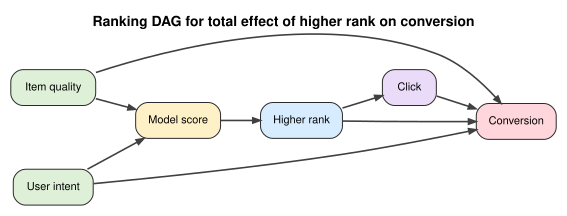

In [15]:
# Organize the calculation into readable steps for the lecture narrative.
ranking_edges = [
    ("User intent", "Model score"),
    ("Item quality", "Model score"),
    ("Model score", "Higher rank"),
    ("User intent", "Conversion"),
    ("Item quality", "Conversion"),
    ("Higher rank", "Click"),
    ("Click", "Conversion"),
    ("Higher rank", "Conversion"),
]
ranking_colors = {
    "Higher rank": "#d7ecff",
    "Conversion": "#ffd6db",
    "User intent": "#dff0d8",
    "Item quality": "#dff0d8",
    "Model score": "#fff1c7",
    "Click": "#eadcf8",
}

smart_display(make_dag(ranking_edges, "Ranking DAG for total effect of higher rank on conversion", ranking_colors))

### Reading the Graph

For the total effect of `Higher rank` on `Conversion`:

- We should account for `User intent` and `Item quality` because they affect both rank assignment and conversion.
- `Model score` can be useful because it summarizes inputs used by the logging policy. Whether it is sufficient depends on whether it captures the relevant common causes.
- We should not adjust for `Click` if we want the total effect, because click is part of the mechanism from rank to conversion.

This distinction matters in ranking projects. A model that controls for clicks can answer a different question: the effect of rank among impressions with the same click status. That differs from the total effect of rank on conversion.

## 11. Simulating the Ranking DAG

Now we simulate data from the ranking graph. We will compare three estimators:

1. Naive regression of conversion on rank.
2. Regression adjusting for pre-treatment common causes.
3. Regression adjusting for pre-treatment variables and the mediator click.

The third model is intentionally included as a warning. It may look more predictive, but it changes the causal estimand.

In [16]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_ranking_dag(n=80_000, seed=44):
    """Generate the synthetic ranking dag data used in 07. Causal DAGs and Graphical Assumptions.

    Args:
        n: Number of simulated units.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng_local = np.random.default_rng(seed)
    user_intent = rng_local.normal(size=n)
    item_quality = rng_local.normal(size=n)
    model_score = 0.9 * user_intent + 0.9 * item_quality + rng_local.normal(scale=0.7, size=n)
    p_high_rank = 1 / (1 + np.exp(-(0.2 + 1.3 * model_score)))
    higher_rank = rng_local.binomial(1, p_high_rank)
    click = 0.85 * higher_rank + 0.55 * user_intent + 0.45 * item_quality + rng_local.normal(size=n)
    conversion = 0.20 * higher_rank + 0.65 * click + 0.65 * user_intent + 0.55 * item_quality + rng_local.normal(size=n)
    return pd.DataFrame({
        "user_intent": user_intent,
        "item_quality": item_quality,
        "model_score": model_score,
        "higher_rank": higher_rank,
        "click": click,
        "conversion": conversion,
    })

df_rank = simulate_ranking_dag()

rank_models = {
    "Naive": smf.ols("conversion ~ higher_rank", data=df_rank).fit(),
    "Adjust common causes": smf.ols("conversion ~ higher_rank + user_intent + item_quality", data=df_rank).fit(),
    "Also adjust mediator click": smf.ols("conversion ~ higher_rank + user_intent + item_quality + click", data=df_rank).fit(),
}

rank_summary = pd.DataFrame({
    "model": list(rank_models.keys()),
    "higher_rank_coefficient": [m.params["higher_rank"] for m in rank_models.values()],
    "std_error": [m.bse["higher_rank"] for m in rank_models.values()],
    "r_squared": [m.rsquared for m in rank_models.values()],
})
rank_summary.round(3)

,model,higher_rank_coefficient,std_error,r_squared
0,Naive,2.114,0.012,0.292
1,Adjust common causes,0.742,0.010,0.627
2,Also adjust mediator click,0.186,0.009,0.739


In Simulating the Ranking DAG, read the model output after checking the graph. Good standard errors do not rescue a coefficient aimed at the wrong causal contrast.

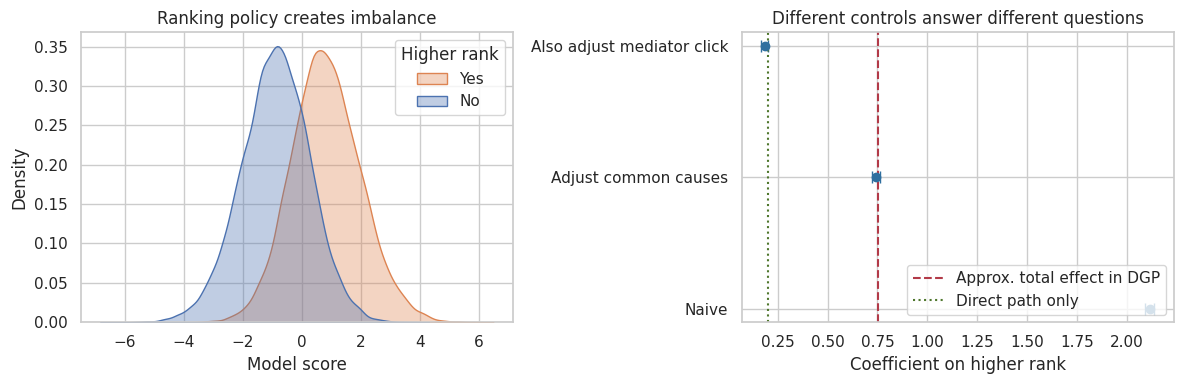

In [17]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(data=df_rank, x="model_score", hue="higher_rank", common_norm=False, fill=True, alpha=0.35, ax=axes[0])
axes[0].set_title("Ranking policy creates imbalance")
axes[0].set_xlabel("Model score")
axes[0].legend(title="Higher rank", labels=["Yes", "No"])

plot_df = rank_summary.copy()
plot_df["lower"] = plot_df["higher_rank_coefficient"] - 1.96 * plot_df["std_error"]
plot_df["upper"] = plot_df["higher_rank_coefficient"] + 1.96 * plot_df["std_error"]
axes[1].errorbar(
    plot_df["higher_rank_coefficient"],
    plot_df["model"],
    xerr=[plot_df["higher_rank_coefficient"] - plot_df["lower"], plot_df["upper"] - plot_df["higher_rank_coefficient"]],
    fmt="o",
    color="#2f6f9f",
    capsize=4,
)
axes[1].axvline(0.20 + 0.65 * 0.85, color="#b23a48", linestyle="--", label="Approx. total effect in DGP")
axes[1].axvline(0.20, color="#4f772d", linestyle=":", label="Direct path only")
axes[1].set_title("Different controls answer different questions")
axes[1].set_xlabel("Coefficient on higher rank")
axes[1].set_ylabel("")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

The naive estimator is inflated because high-ranked items were already better matches for users. Adjusting for pre-treatment common causes moves the estimate toward the total effect of rank.

Adding `click` increases predictive fit, but it blocks the path:

$$
\text{Higher rank} \rightarrow \text{Click} \rightarrow \text{Conversion}.
$$

The coefficient on `higher_rank` now resembles a direct-effect-style quantity, not the total effect. This is a common failure mode in industry modeling: the best predictive control set is not necessarily the right causal adjustment set.

## 12. How to Build a DAG in Practice

A practical DAG-building workflow for an industry causal project:

1. **Write the estimand first.** Treatment, outcome, population, time window, and contrast.
2. **List variables by time order.** Pre-treatment variables, treatment assignment variables, post-treatment mediators, outcomes, and selection variables.
3. **Draw arrows using domain knowledge.** Do not draw arrows just because correlations are high.
4. **Mark unobserved variables.** A DAG should include important latent causes if they affect identification.
5. **List open back-door paths.** These are the biasing paths that must be blocked.
6. **Choose adjustment variables.** Prefer pre-treatment common causes; avoid mediators, colliders, and descendants of colliders for total effects.
7. **Check overlap.** A valid adjustment set still needs data support.
8. **Document sensitivity.** If a key common cause is unobserved, say what would have to be true for the estimate to be credible.

DAGs should be treated as living documents. You revise them when product owners, engineers, clinicians, economists, or domain experts clarify how the system really works.

| step | question_to_answer | deliverable |
|---|---|---|
| Estimand | What exact causal contrast are we estimating? | One-sentence estimand card |
| Temporal ordering | Which variables are measured before treatment, after treatment, or through selection? | Variable timing table |
| Arrows | What causes what according to the system design and domain experts? | First-pass DAG |
| Latent variables | What important causes are not measured? | Observed/unobserved node labels |
| Back-door paths | Which non-causal paths connect treatment and outcome? | Path list |
| Adjustment set | Which pre-treatment variables block those paths without blocking the effect? | Analysis covariate list |
| Overlap | Do treated and untreated units exist across the covariate range? | Balance and propensity diagnostics |
| Sensitivity | How fragile is the conclusion to hidden confounding or graph uncertainty? | Limitations and robustness section |


## 13. Common Mistakes

### Mistake 1: Selecting controls by predictive importance

Predictive importance is about forecasting `Y`. Causal adjustment is about blocking non-causal paths from `T` to `Y`. A variable can be highly predictive and still be a bad control if it is post-treatment.

### Mistake 2: Adjusting for everything available

More controls can increase bias if they include colliders, descendants of colliders, or mediators. A wide feature table still needs a causal adjustment argument.

### Mistake 3: Ignoring selection into the dataset

The dataset itself may be conditioned on a variable: clicked users, active users, approved loans, retained customers, respondents, observed outcomes. Selection mechanisms should appear in the DAG.

### Mistake 4: Leaving out unobserved common causes

If an important common cause is unobserved, the graph should show it. Hiding the node from the DAG does not remove the bias.

### Mistake 5: Treating the DAG as discovered truth

A DAG is a disciplined statement of assumptions. Causal discovery methods can be useful exploratory tools, but for most industry decisions, a DAG still needs substantive knowledge about incentives, timing, product rules, logging systems, and human behavior.

## 14. Key Takeaways

- DAGs encode assumptions about causal structure.
- Confounding is a graphical problem: a back-door path creates non-causal association between treatment and outcome.
- Adjusting for common causes can block biasing paths.
- Adjusting for mediators can remove part of the effect if the estimand is total effect.
- Adjusting for colliders or selection variables can create bias.
- The right adjustment set depends on the estimand, not just the dataset.
- DAGs make assumptions visible, which makes causal analysis easier to critique, improve, and defend.

A strong applied causal analysis usually contains both a graph and an estimator. The graph explains why the estimator targets the causal question. The estimator explains how the target is estimated from data.

## References

Greenland, S., Pearl, J., & Robins, J. M. (1999). Causal diagrams for epidemiologic research. *Epidemiology, 10*(1), 37-48. https://doi.org/10.1097/00001648-199901000-00008

Maathuis, M. H., & Colombo, D. (2015). A generalized back-door criterion. *The Annals of Statistics, 43*(3). https://doi.org/10.1214/14-aos1295

Pearl, J. (1995). Causal diagrams for empirical research. *Biometrika, 82*(4), 669-688. https://doi.org/10.1093/biomet/82.4.669

Pearl, J., & Paz, A. (2014). Confounding equivalence in causal inference. *Journal of Causal Inference, 2*(1), 75-93. https://doi.org/10.1515/jci-2013-0020

Shrier, I., & Platt, R. W. (2008). Reducing bias through directed acyclic graphs. *BMC Medical Research Methodology, 8*(1). https://doi.org/10.1186/1471-2288-8-70

Suttorp, M. M., Siegerink, B., Jager, K. J., Zoccali, C., & Dekker, F. W. (2014). Graphical presentation of confounding in directed acyclic graphs. *Nephrology Dialysis Transplantation, 30*(9), 1418-1423. https://doi.org/10.1093/ndt/gfu325